# Running OGGM with the daily temperature-index mass-balance model

By the end, users should understand how to:

- use OGGM’s daily mass-balance model from the development branch;
- process daily W5E5 climate data;
- recalibrate the daily model using the existing monthly calibration as a starting point (this is only possible because we are using the same basline climate `W5E5` but at a different resolution;
- run glacier evolution with daily hydro diagnostics;
- inspect daily runoff and melt variables.

This is an advanced tutorial because it does not simply use the default monthly OGGM workflow. It modifies the mass-balance model, climate input, calibration suffixes, and diagnostic outputs.

This tutorial is not showing you sensitivity experiments or how to investigate uncertainty. For that referred to:

- [Runoff sensitivity tutorial](https://tutorials.oggm.org/stable/notebooks/tutorials/runoff_sensitivity.html)

## Stage 1 — Environment setup: use OGGM dev branch

```bash
cd ~/oggm
git status
git fetch origin
git checkout -b dev origin/dev
git status
pip install -e .
```
This tutorial requires the OGGM development branch because the daily model functionality is not necessarily available in the stable release used by beginner tutorials. The commands above shwo you how to checkout the dev branch. For this you need to have clone the OGGM repository. 

Follow this instructions if you havent done that:
 - [Install OGGM from source](https://docs.oggm.org/en/stable/installing-oggm.html#from-source-editable)

## Stage 2 — Imports and configuration file

This are all the required imports

In [1]:
# Module logger
import logging
import sys
import configparser
import geopandas as gpd
import xarray as xr
from functools import partial
import numpy as np

from oggm import cfg, utils, workflow, tasks, DEFAULT_BASE_URL
from oggm.exceptions import InvalidParamsError, InvalidWorkflowError
from oggm.shop.w5e5 import process_w5e5_data
from oggm.sandbox import distribute_2d
from oggm.core import massbalance
from oggm.core.flowline import FileModel
from oggm import entity_task
from oggm.utils import float_years_timeseries

In [2]:
log = logging.getLogger(__name__)

In [3]:
cfg.initialize(logging_level='DEBUG')
cfg.PATHS['working_dir'] = utils.gettempdir(dirname='OGGM-daily', reset=True)

2026-06-04 15:59:47: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-06-04 15:59:47: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-06-04 15:59:47: oggm.cfg: Multiprocessing: using all available processors (N=16)


We need the following configuration for OGGM that will allow us to explore all files in the glacier directory

In [4]:
cfg.PARAMS['continue_on_error'] = True
cfg.PARAMS['use_compression'] = True
cfg.PARAMS['use_tar_shapefiles'] = True
cfg.PARAMS['use_temp_bias_from_file'] = True
cfg.PARAMS['compress_climate_netcdf'] = False
cfg.PARAMS['store_model_geometry'] = True
cfg.PARAMS['store_fl_diagnostics'] = True


cfg.PARAMS['use_multiprocessing'] = True
cfg.PARAMS['mp_processes']        = 8
cfg.PARAMS['border']              = 80

2026-06-04 15:59:47: oggm.cfg: PARAMS['continue_on_error'] changed from `False` to `True`.
2026-06-04 15:59:47: oggm.cfg: PARAMS['compress_climate_netcdf'] changed from `True` to `False`.
2026-06-04 15:59:47: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2026-06-04 15:59:47: oggm.cfg: PARAMS['store_fl_diagnostics'] changed from `False` to `True`.
2026-06-04 15:59:47: oggm.cfg: Multiprocessing switched ON after user settings.
2026-06-04 15:59:47: oggm.cfg: Multiprocessing: using the requested number of processors (N=8)


## Stage 3 — Select glaciers within a river catchment in the Alps

We will focus on a group of glaciers within the catchment of a river in the Alps. For that I have computed a specific catchment and selected glaciers within that catchment area which is provided in a vector format in the data directory of this tutorial.

In [5]:
from pathlib import Path

DATA_DIR = Path.cwd().resolve().parents[1] / "Lanzhou_workshop_oggm_tutorials/data"
print(DATA_DIR)

catchment_path = DATA_DIR / 'rofental_river_catchment/deims_sites_boundariesPolygon.shp'
print(catchment_path)

fr = utils.get_rgi_region_file(11, version='62', reset=False)
gdf = gpd.read_file(fr)

rof_shp = gpd.read_file(catchment_path)
rof_sel = gdf.clip(rof_shp)
rof_sel = rof_sel.sort_values('Area', ascending=False)


/home/brecinos/Documents/Lanzhou_workshop_oggm_tutorials/data
/home/brecinos/Documents/Lanzhou_workshop_oggm_tutorials/data/rofental_river_catchment/deims_sites_boundariesPolygon.shp


<Axes: >

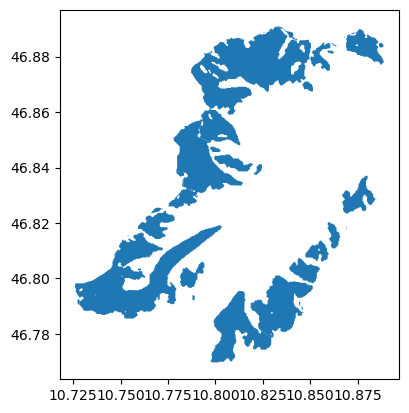

In [6]:
rof_sel.plot()

## Stage 4 — Initialize glacier directories from preprocessing level 4

In this tutorial, we are not changing the glacier outlines, topography or other observations used for calibration. The main change is the temporal resolution of the baseline climate data: we move from monthly to daily climate forcing while still using `W5E5` as the reanalysis product.

Because the glacier geometry and inversion setup are unchanged, we do not need to repeat preprocessing levels 0 to 4. Instead, we start from OGGM preprocessed glacier directories at level 4, using the default OGGM preprocessing URL.

However, the daily mass-balance model uses a different climate file with higher temporal resolution. Therefore, even though the glacier directories already contain a standard calibration, we need to recalibrate the mass-balance model for the daily climate data before running the simulation. Below I show one way of doing this.

In [7]:
base_url = ('https://cluster.klima.uni-bremen.de/~oggm/'
                'gdirs/oggm_v1.6/L3-L5_files/2025.6/elev_bands/W5E5/per_glacier_spinup')

gdirs = workflow.init_glacier_directories(
    rof_sel,
    from_prepro_level=4,
    prepro_base_url=base_url,
    reset=True,
    force=True
)

2026-06-04 15:59:48: urllib3.connectionpool: Starting new HTTPS connection (1): cluster.klima.uni-bremen.de:443
2026-06-04 15:59:48: urllib3.connectionpool: https://cluster.klima.uni-bremen.de:443 "GET /~oggm/gdirs/oggm_v1.6/L3-L5_files/2025.6/elev_bands/W5E5/per_glacier_spinup/RGI62/b_080/L4/ HTTP/1.1" 200 3151
2026-06-04 15:59:48: oggm.workflow: init_glacier_directories from prepro level 4 on 33 glaciers.
2026-06-04 15:59:48: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 33 glaciers


## Stage 5 — Introducion of the daily-model

In the code below we set up a especific OGGM configuration that will give you flexibility and the option to re-calibrate the MB model.

- The `check_calib_params=False` is used here because the tutorial recalibrates the daily model starting from existing calibration information.

In [8]:
DailyTI_nocheck = partial(massbalance.DailyTIModel, check_calib_params=False)

MBModel = DailyTI_nocheck

settings_filesuffix = '_daily'
observations_filesuffix = '_daily'

climate_filename = 'climate_historical_daily'

cfg.PARAMS['baseline_climate'] = 'GSWP3_W5E5_daily'

2026-06-04 15:59:49: oggm.cfg: PARAMS['baseline_climate'] changed from `GSWP3_W5E5` to `GSWP3_W5E5_daily`.


### Get daily climate data

In [9]:
workflow.execute_entity_task(process_w5e5_data, gdirs, daily=True);

2026-06-04 15:59:49: oggm.workflow: Execute entity tasks [process_w5e5_data] on 33 glaciers
2026-06-04 15:59:49: oggm.shop.w5e5: (RGI60-11.00666) process_w5e5_data
2026-06-04 15:59:49: oggm.shop.w5e5: (RGI60-11.00746) process_w5e5_data
2026-06-04 15:59:49: oggm.shop.w5e5: (RGI60-11.00687) process_w5e5_data
2026-06-04 15:59:49: oggm.shop.w5e5: (RGI60-11.00787) process_w5e5_data
2026-06-04 15:59:49: oggm.shop.w5e5: (RGI60-11.00719) process_w5e5_data
2026-06-04 15:59:49: oggm.shop.w5e5: (RGI60-11.00846) process_w5e5_data
2026-06-04 15:59:49: oggm.shop.w5e5: (RGI60-11.00897) process_w5e5_data
2026-06-04 15:59:49: oggm.shop.w5e5: (RGI60-11.00746) process_gswp3_w5e5_data
2026-06-04 15:59:49: oggm.shop.w5e5: (RGI60-11.00719) process_gswp3_w5e5_data
2026-06-04 15:59:49: oggm.shop.w5e5: (RGI60-11.00846) process_gswp3_w5e5_data
2026-06-04 15:59:49: oggm.shop.w5e5: (RGI60-11.00666) process_gswp3_w5e5_data
2026-06-04 15:59:49: oggm.shop.w5e5: (RGI60-11.00897) process_gswp3_w5e5_data
2026-06-04 15:

### Re-calibrate the daily MB model

The preprocessed glacier directories already contain a standard OGGM mass-balance calibration. Here, we use this calibration as the starting point for **re-adjusting** the calibration to the daily model.

We can do this because we are not changing the glacier geometry or the climate product: we still use `W5E5`, and the same glacier outlines, elevation-band flowlines, and ice-thickness inversion remain the same. The main change is the temporal resolution of the mass-balance model, *from monthly to daily*.

For this reason, we keep the original:

- `prcp_fac`, which corrects precipitation biases in the climate data;
- `temp_bias`, which corrects systematic temperature offsets.

We do not recalibrate these parameters here because they describe the climate forcing itself. Recalibrating `prcp_fac`, `temp_bias`, and `melt_f` together would add too much freedom: different parameter combinations could produce a similar annual mass balance.

Instead, we recalibrate only the melt factor, `melt_f`. This parameter is most affected by the change from monthly to daily data, because daily forcing resolves short warm periods that are smoothed in monthly averages.

In this tutorial, the calibration question is therefore:

- Keeping the same W5E5 climate corrections, what daily `melt_f` is needed to reproduce the reference mass balance?

In [10]:
for gdir in gdirs:
    mb_calib = gdir.read_json('mb_calib')
    
    tasks.mb_calibration_from_scalar_mb(
            gdir,
            ref_mb=mb_calib['reference_mb'],
            ref_mb_err=mb_calib['reference_mb_err'],
            ref_mb_period=mb_calib['reference_period'],
            settings_filesuffix=settings_filesuffix,
            observations_filesuffix=observations_filesuffix,
            write_to_gdir=True,
            overwrite_gdir=True,
            overwrite_observations=True,
            calibrate_param1='melt_f',
            calibrate_param2=None,
            calibrate_param3=None,
            prcp_fac=mb_calib['prcp_fac'],
            temp_bias=mb_calib['temp_bias'],
            mb_model_class=MBModel,
            filename=climate_filename
        )

2026-06-04 15:59:50: oggm.core.massbalance: (RGI60-11.00746) mb_calibration_from_scalar_mb_daily
2026-06-04 15:59:50: oggm.core.massbalance: (RGI60-11.00666) mb_calibration_from_scalar_mb_daily
2026-06-04 15:59:50: oggm.core.massbalance: (RGI60-11.00719) mb_calibration_from_scalar_mb_daily
2026-06-04 15:59:50: oggm.core.massbalance: (RGI60-11.00897) mb_calibration_from_scalar_mb_daily
2026-06-04 15:59:50: oggm.core.massbalance: (RGI60-11.00846) mb_calibration_from_scalar_mb_daily
2026-06-04 15:59:50: oggm.core.massbalance: (RGI60-11.00687) mb_calibration_from_scalar_mb_daily
2026-06-04 15:59:50: oggm.core.massbalance: (RGI60-11.00787) mb_calibration_from_scalar_mb_daily
2026-06-04 15:59:50: oggm.core.massbalance: (RGI60-11.00943) mb_calibration_from_scalar_mb_daily
2026-06-04 15:59:50: oggm.core.massbalance: (RGI60-11.00957) mb_calibration_from_scalar_mb_daily
2026-06-04 15:59:50: oggm.core.massbalance: (RGI60-11.00950) mb_calibration_from_scalar_mb_daily
2026-06-04 15:59:50: oggm.core

### Run the daily MB model

In [11]:
# compute apparent MB
workflow.execute_entity_task(tasks.apparent_mb_from_any_mb,
                             gdirs,
                             mb_model_class=MBModel);

2026-06-04 15:59:52: oggm.workflow: Execute entity tasks [apparent_mb_from_any_mb] on 33 glaciers
2026-06-04 15:59:52: oggm.core.massbalance: (RGI60-11.00666) apparent_mb_from_any_mb
2026-06-04 15:59:52: oggm.core.massbalance: (RGI60-11.00787) apparent_mb_from_any_mb
2026-06-04 15:59:52: oggm.core.massbalance: (RGI60-11.00687) apparent_mb_from_any_mb
2026-06-04 15:59:52: oggm.core.massbalance: (RGI60-11.00746) apparent_mb_from_any_mb
2026-06-04 15:59:52: oggm.core.massbalance: (RGI60-11.00897) apparent_mb_from_any_mb
2026-06-04 15:59:52: oggm.core.massbalance: (RGI60-11.00719) apparent_mb_from_any_mb
2026-06-04 15:59:52: oggm.core.massbalance: (RGI60-11.00846) apparent_mb_from_any_mb
2026-06-04 15:59:52: oggm.core.massbalance: (RGI60-11.00943) apparent_mb_from_any_mb
2026-06-04 15:59:52: oggm.core.massbalance: (RGI60-11.00950) apparent_mb_from_any_mb
2026-06-04 15:59:52: oggm.core.massbalance: (RGI60-11.00957) apparent_mb_from_any_mb
2026-06-04 15:59:52: oggm.core.massbalance: (RGI60-1

### Calibrate ice dynamic parameters to match a reference Volume

In [12]:
# calibrate ice dynamic params
workflow.calibrate_inversion_from_consensus(
    gdirs,
    apply_fs_on_mismatch=True,
    error_on_mismatch=True,  # if you're running many glaciers some might not work
    filter_inversion_output=True,  # this partly filters the over deepening due to
    #    # the equilibrium assumption for retreating glaciers (see. Figure 5 of Maussion et al. 2019)
);

2026-06-04 15:59:52: oggm.workflow: Applying global task calibrate_inversion_from_consensus on 33 glaciers
2026-06-04 15:59:52: oggm.workflow: Applying global task calibrate_inversion_from_volume on 33 glaciers
2026-06-04 15:59:52: oggm.workflow: Volume estimate optimisation with A factor: 0.1 and fs: 0
2026-06-04 15:59:52: oggm.workflow: Applying global task inversion_tasks on 33 glaciers
2026-06-04 15:59:52: oggm.workflow: Execute entity tasks [prepare_for_inversion] on 33 glaciers
2026-06-04 15:59:52: oggm.core.inversion: (RGI60-11.00666) prepare_for_inversion
2026-06-04 15:59:52: oggm.core.inversion: (RGI60-11.00687) prepare_for_inversion
2026-06-04 15:59:52: oggm.core.inversion: (RGI60-11.00746) prepare_for_inversion
2026-06-04 15:59:52: oggm.core.inversion: (RGI60-11.00719) prepare_for_inversion
2026-06-04 15:59:52: oggm.core.inversion: (RGI60-11.00787) prepare_for_inversion
2026-06-04 15:59:52: oggm.core.inversion: (RGI60-11.00897) prepare_for_inversion
2026-06-04 15:59:52: oggm

### Initialise present day glacier.

In [13]:
workflow.execute_entity_task(tasks.init_present_time_glacier, gdirs);

2026-06-04 15:59:54: oggm.workflow: Execute entity tasks [init_present_time_glacier] on 33 glaciers


## Stage 6 — Run the daily model with hydro diagnostics

In [14]:
from daily_model_tools import run_with_hydro_daily

> **Important**
>
> `run_with_hydro_daily` is not currently a standard OGGM task. It was adapted for this tutorial from the [OGGM mass-balance sandbox](https://github.com/OGGM/massbalance-sandbox) and related daily mass-balance/runoff work. We use it here as a prototype to explore daily hydro diagnostics.
>
> Future OGGM versions may include similar functionality, but the official implementation may compute or store runoff variables differently.

In [15]:
cfg.PARAMS['store_model_geometry'] = True

y0 = 1980
y1 = 2019

simulation_name = '_climate_historical_daily'

workflow.execute_entity_task(
            run_with_hydro_daily,
            gdirs,
            settings_filesuffix=settings_filesuffix,
            run_task=tasks.run_from_climate_data,
            ys=y0, ye=y1,
            climate_filename=climate_filename,
            climate_input_filesuffix='',
            mb_model_class=DailyTI_nocheck,
            output_filesuffix=simulation_name,
            mb_elev_feedback='annual',
            store_monthly_step=False,
            store_annual=True,
        );

2026-06-04 15:59:54: oggm.workflow: Execute entity tasks [run_with_hydro_daily] on 33 glaciers
2026-06-04 15:59:55: daily_model_tools: (RGI60-11.00719) run_with_hydro_daily_daily_climate_historical_daily
2026-06-04 15:59:55: daily_model_tools: (RGI60-11.00787) run_with_hydro_daily_daily_climate_historical_daily
2026-06-04 15:59:55: daily_model_tools: (RGI60-11.00666) run_with_hydro_daily_daily_climate_historical_daily
2026-06-04 15:59:55: daily_model_tools: (RGI60-11.00897) run_with_hydro_daily_daily_climate_historical_daily
2026-06-04 15:59:55: daily_model_tools: (RGI60-11.00687) run_with_hydro_daily_daily_climate_historical_daily
2026-06-04 15:59:55: daily_model_tools: (RGI60-11.00846) run_with_hydro_daily_daily_climate_historical_daily
2026-06-04 15:59:55: oggm.core.flowline: (RGI60-11.00787) run_from_climate_data_daily_climate_historical_daily
2026-06-04 15:59:55: daily_model_tools: (RGI60-11.00746) run_with_hydro_daily_daily_climate_historical_daily
2026-06-04 15:59:55: oggm.core.

## What about future simulations?

In this tutorial, we use daily `W5E5` to demonstrate the daily mass-balance model and to compute daily hydro diagnostics for the historical period. However, most future climate scenarios used in OGGM are available as monthly bias-corrected climate files, not daily files.

Therefore, we do not extend `run_with_hydro_daily` to future projections here. Instead, the recommended workflow is:

- use the daily model for historical experiments and process understanding;
- use the standard monthly OGGM workflow for future projections;
- compare daily and monthly historical simulations to estimate how much the temporal resolution affects melt, snowfall, liquid precipitation, and runoff diagnostics in your study region.
